In [1]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import jaccard_score
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

### Iš anksto paruošiam įvairius embedding'us

In [2]:
distance_matrix = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels = np.load('ship-types.npy')

# Projekcijų sudarymas ir įvertinimas

In [3]:
embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=42
).fit_transform(distance_matrix)

embedding25 = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=25,
    method='exact',
    random_state=42
).fit_transform(distance_matrix)

embedding100 = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    n_components=100,
    max_iter=500,
    method='exact',
    random_state=42
).fit_transform(distance_matrix)

In [4]:
from zadu.measures import class_aware_trustworthiness_continuity

In [5]:
def measure_continuity_trustworthiness(
    original_flat: np.ndarray,
    embedding: np.ndarray,
    labels: np.ndarray[str]
) -> tuple[float]:
    
    trust_scores = []
    cont_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(ca_tc["ca_trustworthiness"])
        cont_scores.append(ca_tc["ca_continuity"])

    trust_score = float(np.mean(trust_scores))
    cont_score = float(np.mean(cont_scores))

    return cont_score, trust_score

In [6]:
original_flat = original_data.reshape((-1, 250))
cont2, trust2 = measure_continuity_trustworthiness(
    original_flat, embedding, labels
)

cont25, trust25 = measure_continuity_trustworthiness(
    original_flat, embedding25, labels
)

cont100, trust100 = measure_continuity_trustworthiness(
    original_flat, embedding100, labels
)

In [7]:
import pandas as pd

data = {
    "Dimensija": [2, 25, 100],
    "Tęstinumas": [cont2, cont25, cont100],
    "Patikimumas": [trust2, trust25, trust100],
}

print(pd.DataFrame(data)\
    .to_latex()\
    .replace('.', ','))

\begin{tabular}{lrrr}
\toprule
 & Dimensija & Tęstinumas & Patikimumas \\
\midrule
0 & 2 & 0,987661 & 0,980828 \\
1 & 25 & 0,982749 & 0,966229 \\
2 & 100 & 0,978805 & 0,959402 \\
\bottomrule
\end{tabular}



> Kadangi tiek tęstinumo, tiek patikimumo viršija 0,95, tai yra labai gera projekcija lokalios struktūros atžvilgiu -> mes naudosime šitą dimensijos mažinimą toliau

# Hierarchinis klasterizavimas

In [8]:
n = original_data.shape[0]
np.sqrt(n / 2)

np.float64(19.364916731037084)

#### Maksimum 20 klasterių tikrinsime 

In [9]:
def calculate_wcbcr(clusters, distance_matrix):
    """ Calculate Within-Cluster to Between-Cluster Ratio (WCBCR). """

    clusters = np.array(clusters)
    distance_matrix = np.array(distance_matrix)
    unique_clusters = np.unique(clusters)

    # Group point indices by cluster label
    # Key - cluster number, value - list of indices that belong to that cluster number 
    cluster_members = {k: np.where(clusters == k)[0] for k in unique_clusters}

    # Compute medoid for each cluster
    centroids = {}
    for k, members in cluster_members.items():
        if len(members) == 1:
            centroids[k] = members[0]
        else:
            intra_distances = [sum(distance_matrix[p][q] for q in members) for p in members]
            centroids[k] = members[np.argmin(intra_distances)]

    # Numerator: sum of distances from each point to its cluster medoid
    numerator = sum(
        distance_matrix[point][centroids[k]]
        for k, members in cluster_members.items()
        for point in members
    )

    # Denominator: sum of distances between all distinct centroid pairs (i ≠ j)
    centroid_list = list(centroids.values())
    K = len(centroid_list)
    denominator = sum(
        distance_matrix[centroid_list[i]][centroid_list[j]]
        for i in range(K)
        for j in range(K)
        if i != j
    )

    if denominator == 0:
        raise ValueError("Denominator is zero: all centroids are identical.")

    return numerator / denominator

def inertia_score(embeddings, clusters):
    clusters = np.array(clusters)
    unique_clusters = np.unique(clusters)
    inertia = 0.0

    for cluster_id in unique_clusters:
        # Get all points belonging to this cluster
        mask = clusters == cluster_id
        cluster_points = embeddings[mask]
        
        # Calculate centroid
        centroid = cluster_points.mean(axis=0)
        
        # Sum of squared euclidean distances from each point to its centroid
        diff = cluster_points - centroid
        inertia += np.sum(diff ** 2)
    
    return inertia

In [10]:
def evaluate_clustering_dist_mat(dist_mat, max_n):
    silhouette_scores = []
    inertia_scores = []

    for n in range(2, max_n):
        clusters = AgglomerativeClustering(n_clusters=n, metric='precomputed', linkage='average')\
            .fit_predict(dist_mat)

        score = silhouette_score(dist_mat, clusters, metric='precomputed')
        silhouette_scores.append(score)

        # Elbow method: compute inertia (mean intra-cluster distance)
        wcbcr = calculate_wcbcr(clusters, dist_mat)
        inertia_scores.append(wcbcr)

    return silhouette_scores, inertia_scores

def evaluate_clustering_embeddings(embedding, max_n):
    silhouette_scores = []
    inertia_scores = []

    for n in range(2, max_n):
        clusters = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='average')\
            .fit_predict(embedding)

        score = silhouette_score(embedding, clusters, metric='euclidean')
        silhouette_scores.append(score)

        # Elbow method: compute inertia (mean intra-cluster distance)
        inertia = inertia_score(embedding, clusters)
        inertia_scores.append(inertia)

    return silhouette_scores, inertia_scores

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [12]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

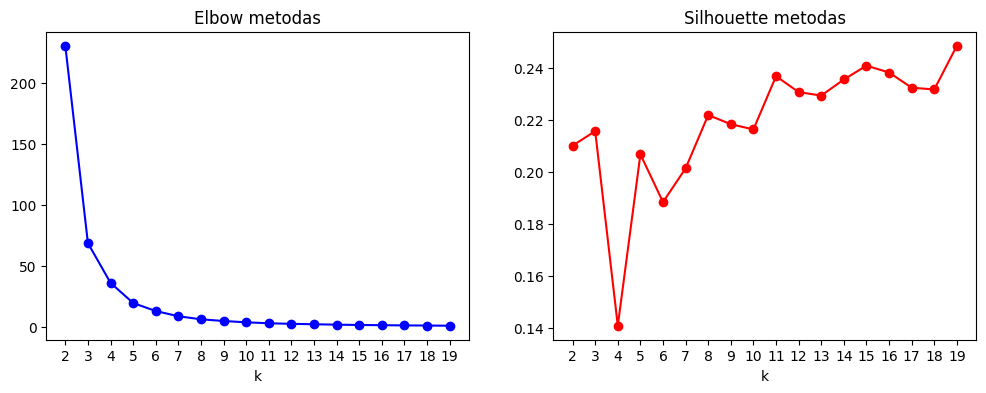

In [13]:
silhouette_scores, wcbrc = evaluate_clustering_dist_mat(distance_matrix, 20)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

### Pagal siluetus: 20, pagal elbow - 5

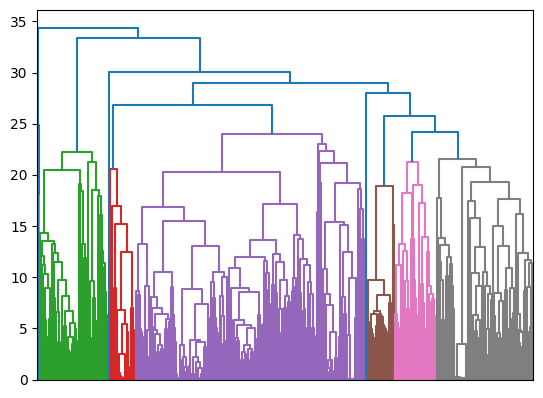

In [14]:
model = AgglomerativeClustering(
    20, metric='precomputed',
    linkage='average',
    compute_distances=True 
)

clusters20 = model.fit_predict(distance_matrix)
clusters5 = AgglomerativeClustering(
    5, metric='precomputed',
    linkage='average',
    compute_distances=True 
).fit_predict(distance_matrix)

plot_dendrogram(model, truncate_mode="level")
plt.xticks(ticks=[], labels=[])
plt.show()

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

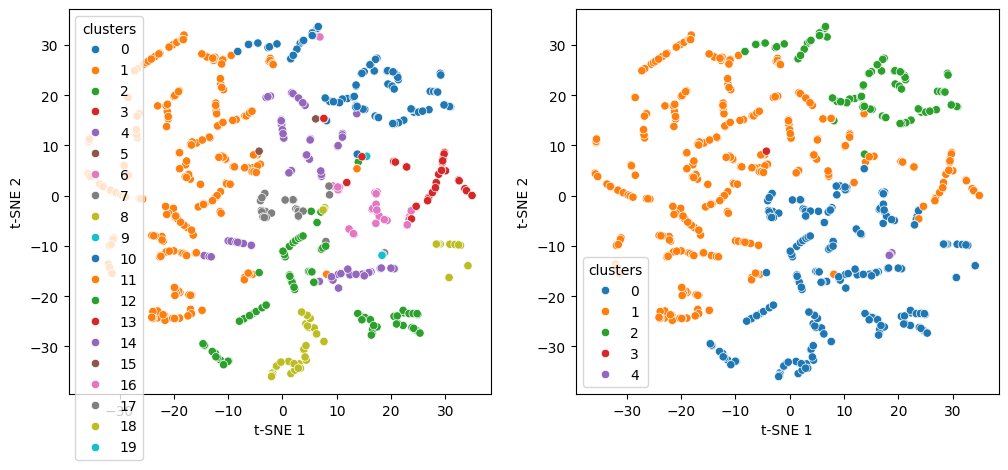

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[0],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters5

n_clusters = len(np.unique(clusters5))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 2

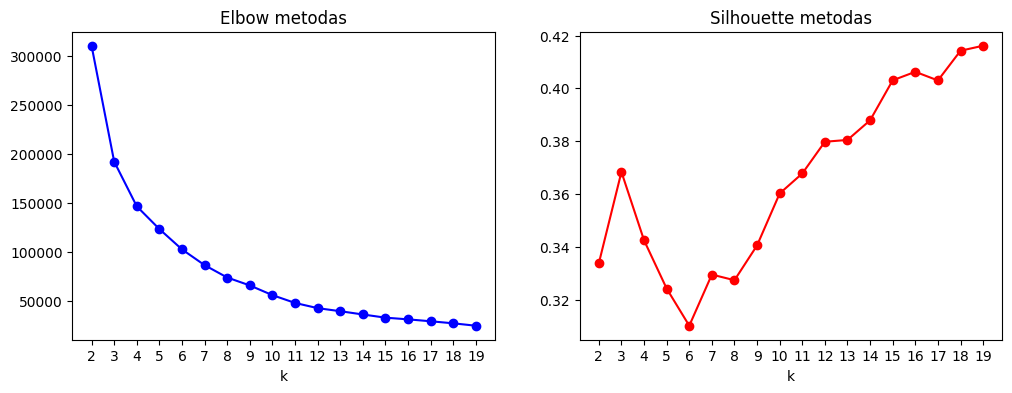

In [27]:
silhouette_scores, inertia_scores = evaluate_clustering_embeddings(embedding, max_n=20)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), inertia_scores, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

### Pagal elbow metodą - 10, pagal siluetus - 20

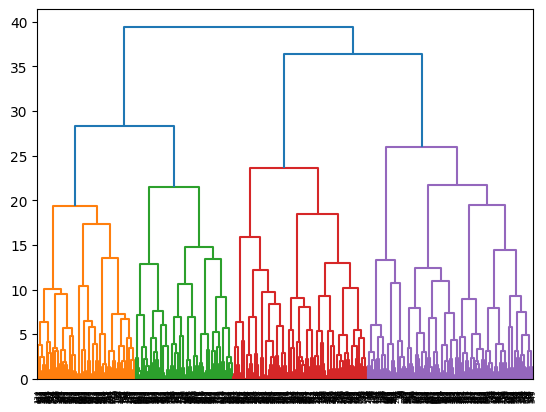

In [17]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='average',
    compute_distances=True 
)

clusters = model.fit_predict(embedding)

plot_dendrogram(model, truncate_mode="level")

In [ ]:
clusters5 = AgglomerativeClustering(
    10, metric='euclidean',
    linkage='average',
    compute_distances=True 
).fit_predict(embedding)

clusters20 = AgglomerativeClustering(
    20, metric='euclidean',
    linkage='average',
    compute_distances=True 
).fit_predict(embedding)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

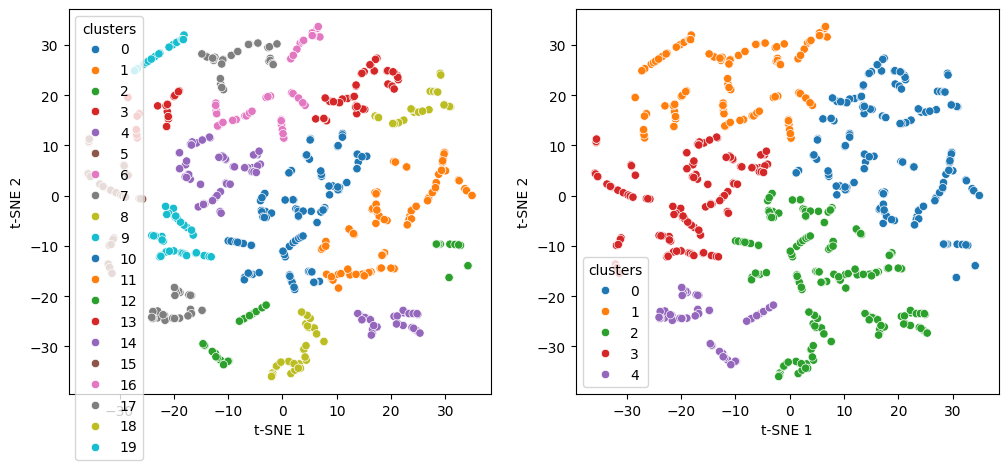

In [19]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[0],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters5

n_clusters = len(np.unique(clusters5))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 25

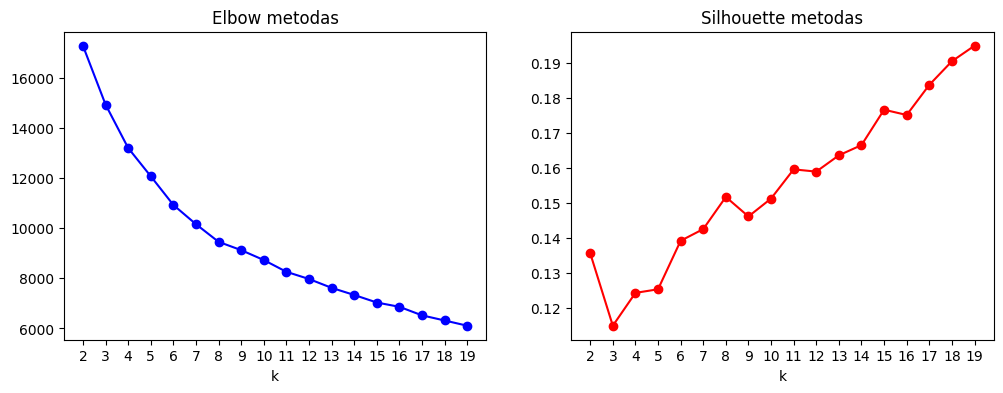

In [26]:
silhouette_scores, inertia_scores = evaluate_clustering_embeddings(embedding25, max_n=20)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), inertia_scores, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

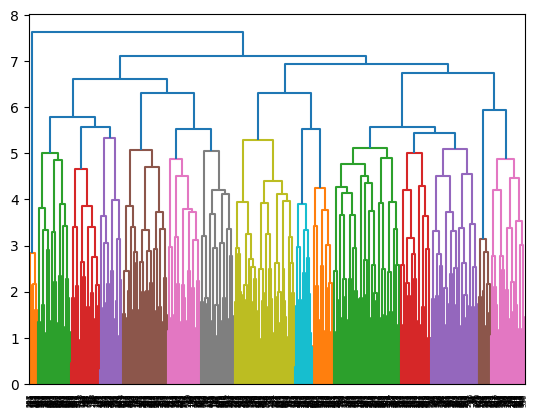

In [21]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='average',
    compute_distances=True 
)

clusters = model.fit_predict(embedding25)

plot_dendrogram(model, truncate_mode="level")

In [ ]:
clusters20 = AgglomerativeClustering(
    20, metric='euclidean',
    linkage='average',
    compute_distances=True 
).fit_predict(embedding25)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

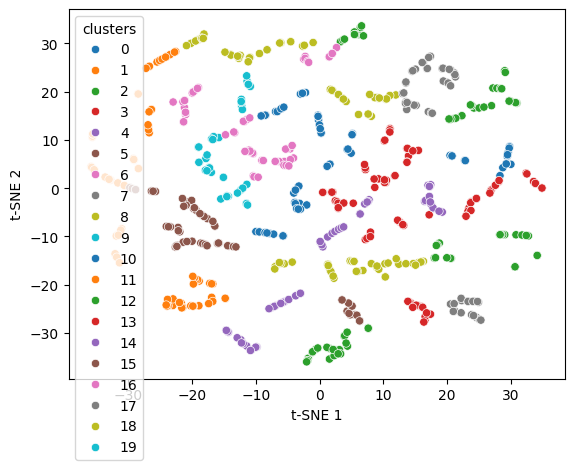

In [28]:
df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 100

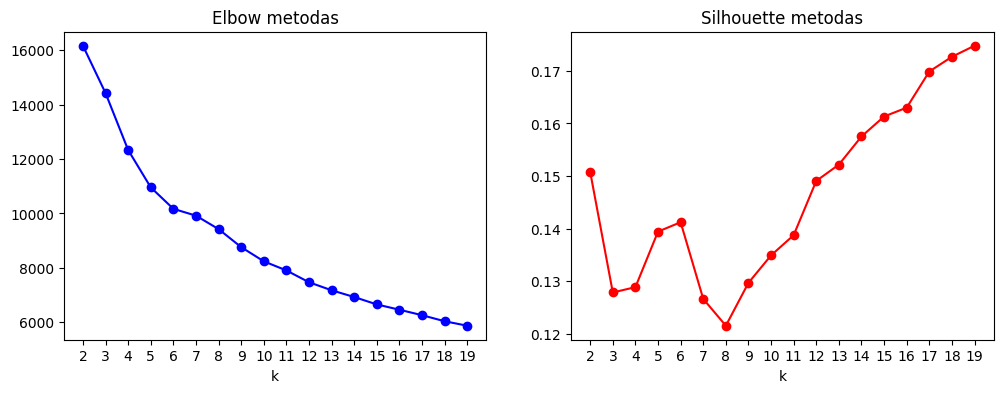

In [24]:
silhouette_scores, inertia_scores = evaluate_clustering_embeddings(embedding100, max_n=20)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), inertia_scores, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

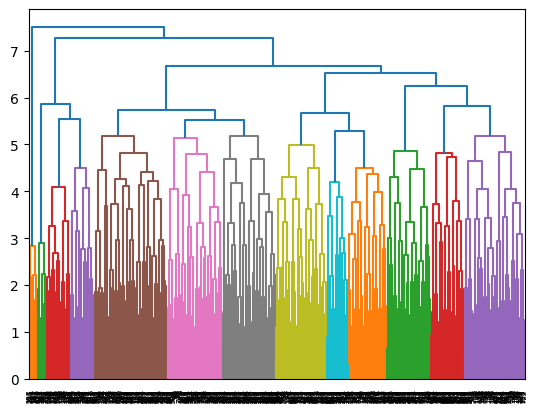

In [31]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='average',
    compute_distances=True 
)

clusters = model.fit_predict(embedding100)

plot_dendrogram(model, truncate_mode="level")

In [29]:
clusters20 = AgglomerativeClustering(
    20, metric='euclidean',
    linkage='average',
    compute_distances=True 
).fit_predict(embedding100)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

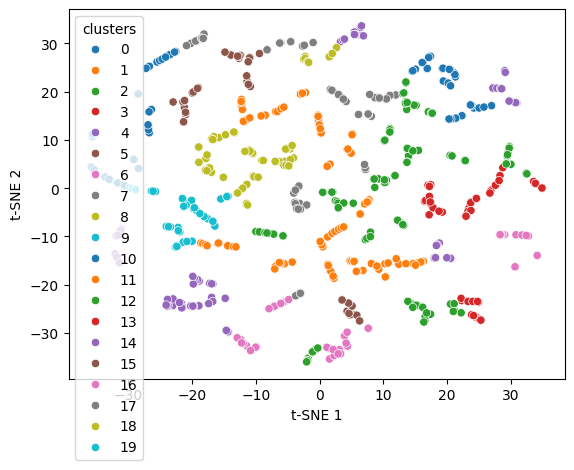

In [30]:
df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

# K-means

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score,
                             jaccard_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon


## duomenu paruosimas

In [52]:
# --- 1 & 2. DUOMENŲ PARUOŠIMAS ---
original_data = np.load('original_data.npy')
labels_true_str = np.load('ship-types.npy')
le = LabelEncoder()
labels_true = le.fit_transform(labels_true_str)

data_2d = original_data.reshape(original_data.shape[0], -1) if original_data.ndim > 2 else original_data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_2d)


## elbow & silhouette

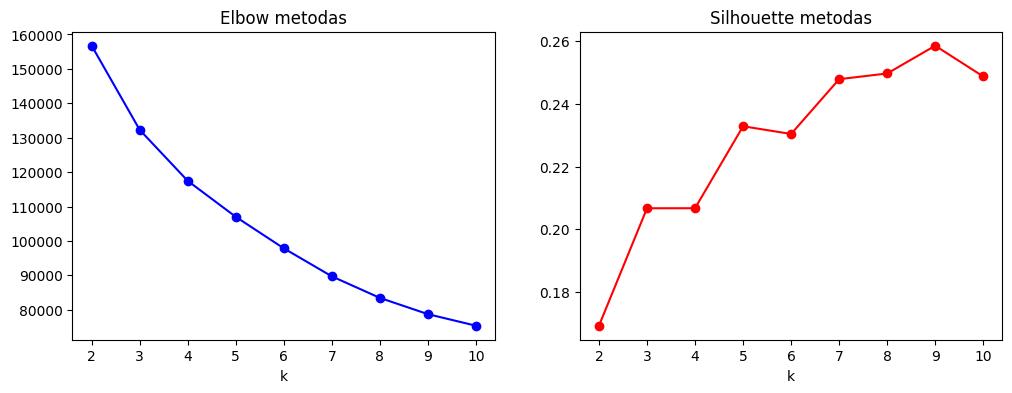

In [53]:

ks = list(range(2, 11))
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(data_scaled, km.labels_))

# Grafikų braižymas vizualiam vertinimui
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(ks, inertias, 'bo-'); plt.title('Elbow metodas'); plt.xlabel('k')
plt.subplot(1, 2, 2); plt.plot(ks, silhouettes, 'ro-'); plt.title('Silhouette metodas'); plt.xlabel('k')
plt.show()

## optmimalaus k radimas

In [54]:
# 1. Empyrinis 
emp_k = len(np.unique(labels_true_str))
print(f"1. Empyrinis metodas: k = {emp_k}")

# 2. Elbow 
x1, y1 = ks[0], inertias[0]
x2, y2 = ks[-1], inertias[-1]
distances = []
for i in range(len(ks)):
    x0, y0 = ks[i], inertias[i]
    numerator = abs((x2 - x1) * (y1 - y0) - (x1 - x0) * (y2 - y1))
    denominator = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    distances.append(numerator / denominator)
elbow_k = ks[np.argmax(distances)]
print(f"2. Elbow (Alkūnės) metodas:  k = {elbow_k}")

# 3. Silhouette 
sil_k = ks[np.argmax(silhouettes)]
print(f"3. Vidutinio silueto metodas:   k = {sil_k}")

optimal_k = 5 #(5/9)

1. Empyrinis metodas: k = 5
2. Elbow (Alkūnės) metodas:  k = 5
3. Vidutinio silueto metodas:   k = 9


## og vs tsne dimensija

/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_51349/3974218807.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', optimal_k)


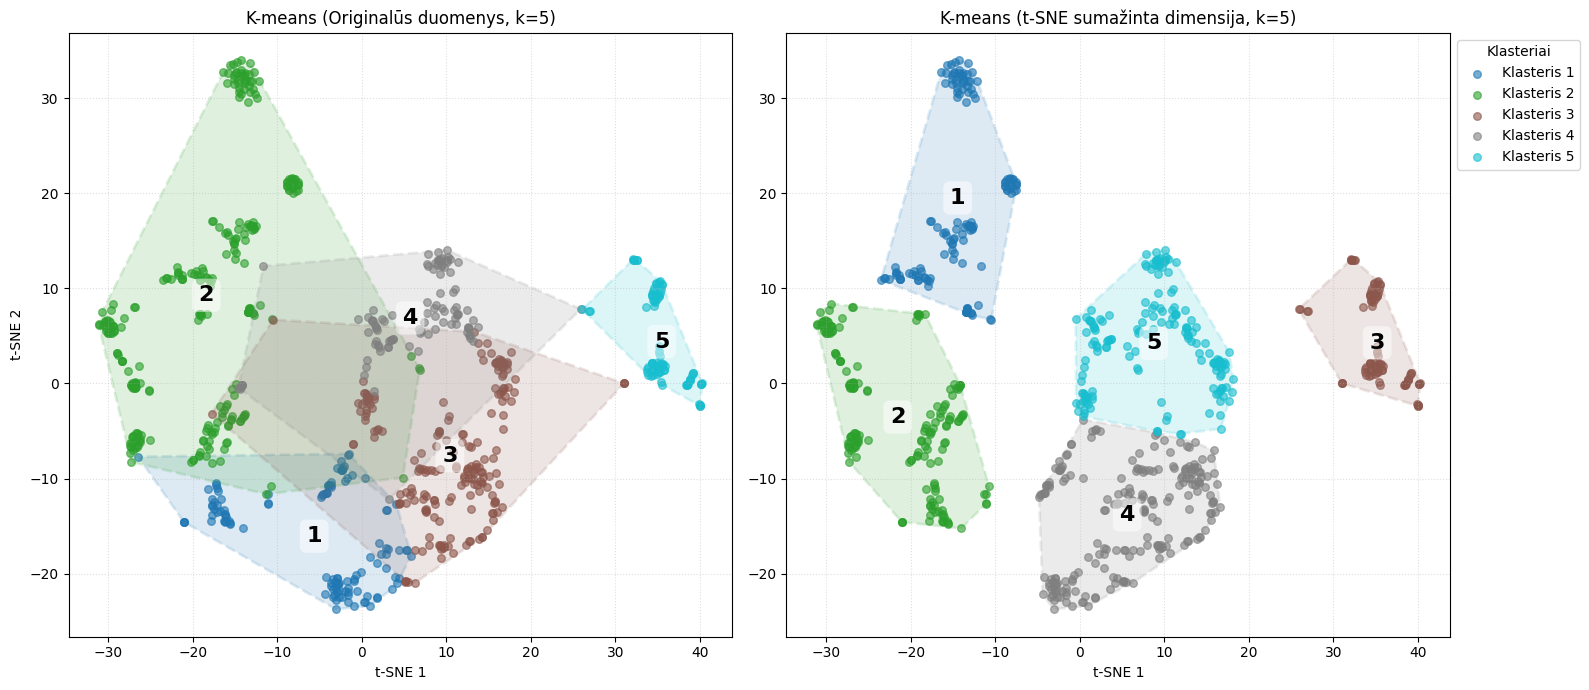

In [55]:
# A. Klasterizavimas ant ORIGINALŲ duomenų
km_orig = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_orig = km_orig.fit_predict(data_scaled)

# B. Klasterizavimas ant SUMAŽINTOS DIMENSIJOS (t-SNE)
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(data_scaled)
km_tsne = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_reduced = km_tsne.fit_predict(data_tsne)



# --- VIZUALIZACIJA (Atnaujinta pagal jūsų pavyzdį) ---
def plot_fancy_clusters(ax, data_2d_plot, labels, title):
    colors = plt.cm.get_cmap('tab10', optimal_k)
    for i in range(optimal_k):
        points = data_2d_plot[labels == i]
        ax.scatter(points[:, 0], points[:, 1], s=30, color=colors(i), label=f'Klasteris {i+1}', alpha=0.6)
        
        if len(points) > 2:
            hull = ConvexHull(points)
            poly = Polygon(points[hull.vertices], facecolor=colors(i), 
                           alpha=0.15, edgecolor=colors(i), lw=2, linestyle='--')
            ax.add_patch(poly)
            
            center = np.mean(points, axis=0)
            ax.text(center[0], center[1], str(i+1), fontsize=16, weight='bold', 
                     color='black', ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round'))
            
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

plot_fancy_clusters(ax1, data_tsne, labels_orig, f"K-means (Originalūs duomenys, k={optimal_k})")
ax1.set_xlabel("t-SNE 1")
ax1.set_ylabel("t-SNE 2")

plot_fancy_clusters(ax2, data_tsne, labels_reduced, f"K-means (t-SNE sumažinta dimensija, k={optimal_k})")
ax2.set_xlabel("t-SNE 1")

ax2.legend(title="Klasteriai", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## matai

In [56]:
def get_metrics(data, labels_pred, labels_true):
    return {
        "Silhouette": silhouette_score(data, labels_pred),
        "Calinski-Harabasz": calinski_harabasz_score(data, labels_pred),
        "Davies-Bouldin": davies_bouldin_score(data, labels_pred),
        "ARI": adjusted_rand_score(labels_true, labels_pred),
        "NMI": normalized_mutual_info_score(labels_true, labels_pred),
        "Jaccard": jaccard_score(labels_true, labels_pred, average='weighted')
    }

metrics_orig = get_metrics(data_scaled, labels_orig, labels_true)
metrics_tsne = get_metrics(data_tsne, labels_reduced, labels_true)

df_metrics = pd.DataFrame([metrics_orig, metrics_tsne], index=['Originalūs duomenys', 't-SNE duomenys'])
print("\n--- Klasterizavimo kokybės palyginimas ---")
print(df_metrics.T)

# ------
df_analysis = pd.DataFrame(data_2d)
df_analysis['klasteris'] = labels_orig

print("\n--- Klasterių vidurkiai (tendencijos) ---")
summary = df_analysis.groupby('klasteris').mean()
print(summary.iloc[:, :5]) 


--- Klasterizavimo kokybės palyginimas ---
                   Originalūs duomenys  t-SNE duomenys
Silhouette                    0.232874        0.507314
Calinski-Harabasz           140.126374     1143.241821
Davies-Bouldin                1.521135        0.713473
ARI                           0.120542        0.109461
NMI                           0.161059        0.185679
Jaccard                       0.172703        0.091749

--- Klasterių vidurkiai (tendencijos) ---
                  0         1         2         3         4
klasteris                                                  
0          0.677905  0.204139  0.475970  0.385509  0.336978
1          0.786526  0.362170  0.482489  0.076116  0.682013
2          0.537920  0.415071  0.486845  0.385950  0.919203
3          0.518117  0.174311  0.480138  0.371723  0.449063
4          0.517423  0.888233  0.547323  0.412687  0.952179
